In [1]:
!pip install -r ../requirements.txt

In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

12.8
True


In [3]:
import sys
import importlib
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.d3qn_per_lstm_with_mask_action as d3qn_per_agent
import configurations.config_p3_sub1 as config

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config)

device used:  cuda
device used:  cuda


<module 'configurations.config_p3_sub1' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p3_sub1.py'>

In [4]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.d3qn_per_lstm_with_mask_action import D3QN_PER
from configurations.config_p3_sub1 import config

In [5]:
print(config)

{'seed': 333, 'gamma': 0.999, 'bufferSize': 100000, 'batchSize': 64, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.0007, 'MAX_TRAIN_EPISODES': 200, 'MAX_EVAL_EPISODES': 5, 'updateFrequency': 100, 'explorationStrategyTrainFn': <function selectEpsilonGreedyAction at 0x00000254A4BFBEC0>, 'explorationStrategyEvalFn': <function selectGreedyAction at 0x00000254A4BFBE20>, 'max_steps': 1000, 'epochs': 20, 'epsilon': 0.58, 'eps_decay_strategy': [('exponential', {'s': 0, 'e': 249, 'ival': 1.0, 'fval': 0.005})], 'device': device(type='cuda'), 'delta': 0.99, 'tau': 0.001, 'alpha': 0.58, 'beta': 0.42, 'beta_rate': 0.0002, 'f_hDim': [512, 256], 'lstm_hDim': 128, 'model_path': '../model_weights_phase3_sub1', 'loss_fn': 'HuberLoss', 'seq_len': 30, 'burn_in': 15, 'mask_lambda': 0.05, 'mask_threshold': -80.0, 'minSamples': 2, 'sampleAction': True}


In [6]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=3,
    box_speed=4,
)
d3qnPerwithLSTMAgent = D3QN_PER(env, config)

In [7]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList, d3qnPerWallClockTimeList, d3qnPerTotalStepsList, d3qnPerFinalEvalReward = d3qnPerwithLSTMAgent.runD3QN_PER()

Episode 0: TR -11933.0 | ER -56468.0 | TT 3.3232369422912598 | WC 38.690210819244385 | TS 263
Episode 1: TR -38371.0 | ER -39960.2 | TT 46.47949552536011 | WC 84.40007829666138 | TS 1000
Episode 2: TR -35988.0 | ER -941.0 | TT 97.92348456382751 | WC 136.7205262184143 | TS 1000
Episode 3: TR -52686.0 | ER -37079.6 | TT 149.0945599079132 | WC 186.7977192401886 | TS 1000
Episode 4: TR -35370.0 | ER -194009.6 | TT 199.00561046600342 | WC 238.63211512565613 | TS 1000
Episode 5: TR -25668.0 | ER -895.4 | TT 250.93818998336792 | WC 289.02342891693115 | TS 1000
Episode 6: TR -11684.0 | ER -48220.0 | TT 301.5913436412811 | WC 333.21900701522827 | TS 1000
Episode 7: TR -18572.0 | ER -934.8 | TT 345.84481930732727 | WC 385.16442036628723 | TS 1000
Episode 8: TR -868.0 | ER -70858.4 | TT 397.74887585639954 | WC 420.4728136062622 | TS 1000
Episode 9: TR -6071.0 | ER -932.0 | TT 432.5186388492584 | WC 469.9743740558624 | TS 1000
Episode 10: TR -7569.0 | ER -194582.2 | TT 483.3990228176117 | WC 520.7

In [8]:
import numpy as np
print(f"D3QN_PER Final Evaluation Reward: {np.mean(d3qnPerFinalEvalReward).item()}")

D3QN_PER Final Evaluation Reward: -172619.6


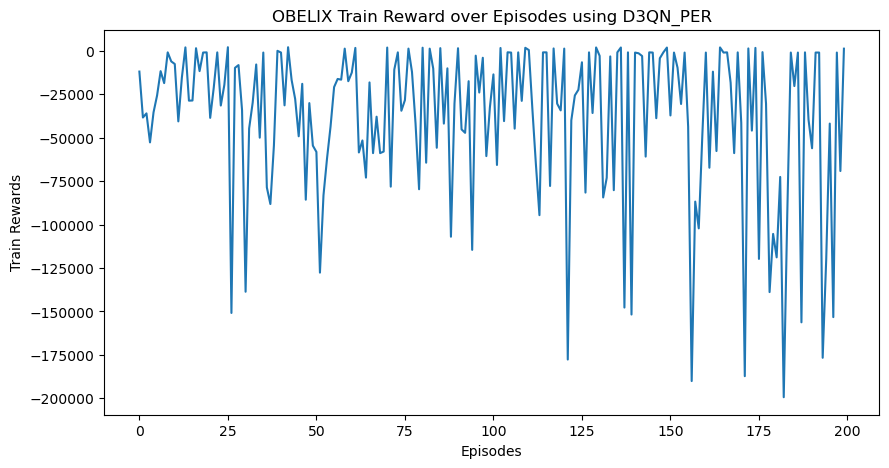

In [9]:
plotQuantity(
    d3qnPerTrainRewardsList, 
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER"]    
)

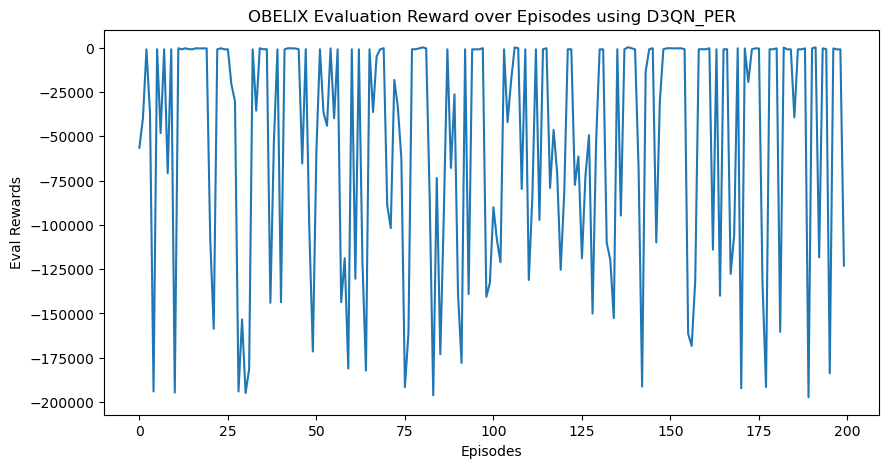

In [10]:
plotQuantity(
    d3qnPerEvalRewardsList, 
    len(d3qnPerEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using D3QN_PER"]    
)

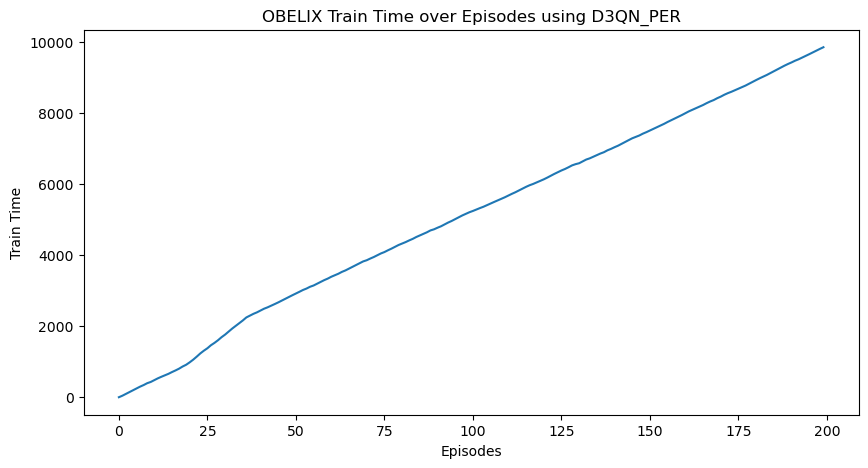

In [11]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER"]    
)

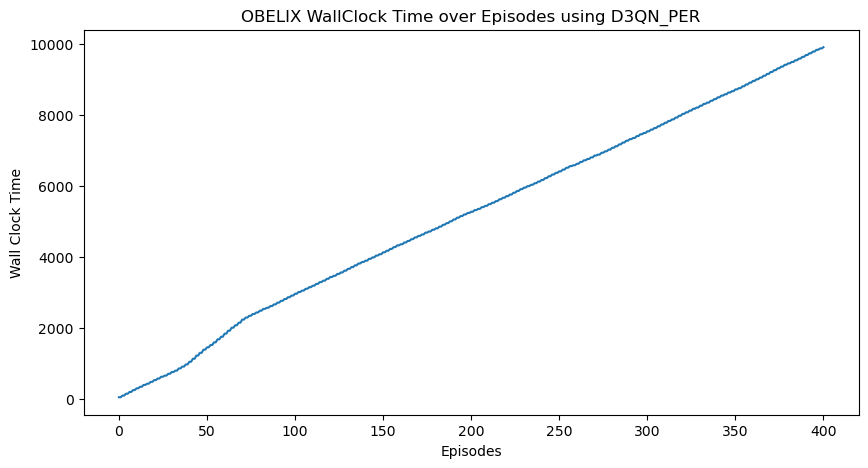

In [12]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER"]    
)

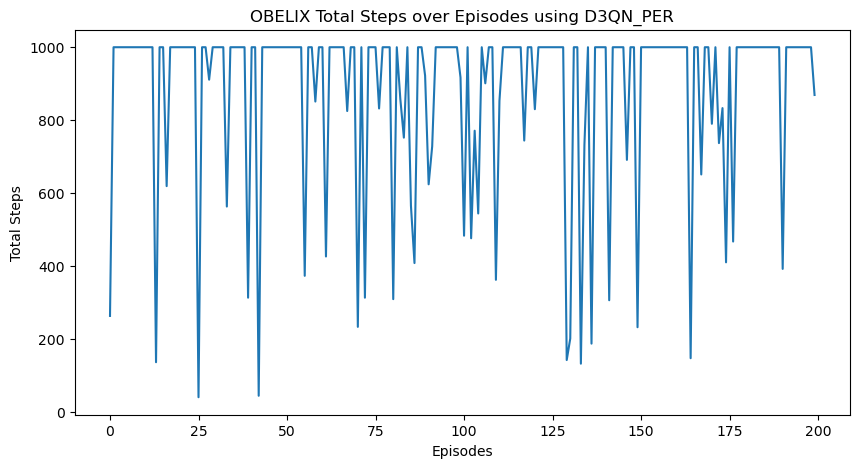

In [13]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER"]    
)